In [1]:
import warnings 
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta, date
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import math

In [2]:
#Lectura de los datos en bruto y eliminación de espacios
metadata=pd.read_csv("../Datos en bruto/Meteorologicos/Viento/stations.txt",skiprows=17,sep=",")
metadata.columns=metadata.columns.str.strip()
metadata.CN=metadata.CN.str.strip()
metadata.STANAME=metadata.STANAME.str.strip()
metadata

,STAID,STANAME,CN,LAT,LON,HGHT
0,5,LINKOEPING-MALMSLAETT,SE,+58:24:00,+015:31:59,93
1,7,KARLSTAD-AIRPORT,SE,+59:26:40,+013:20:15,107
2,11,KREMSMUENSTER (TAWES),AT,+48:03:18,+014:07:51,382
3,12,GRAZ-UNIVERSITAET,AT,+47:04:40,+015:26:56,367
4,13,INNSBRUCK-UNIV,AT,+47:15:36,+011:23:03,578
...,...,...,...,...,...,...
6222,27904,VICENZA - SANT'AGOSTINO,IT,+45:31:27,+011:31:13,29
6223,27905,MONTE CESEN,IT,+45:56:43,+012:01:14,1552
6224,27912,MONTE VERENA,IT,+45:55:50,+011:24:50,2008
6225,27940,BARKALD,NO,+61:59:30,+010:53:11,452


In [3]:
#Filtrado de datos para España
metadata_ESP=metadata[metadata.CN=='ES']
metadata_ESP

,STAID,STANAME,CN,LAT,LON,HGHT
87,229,BADAJOZ AEROPUERTO,ES,+38:52:59,-006:48:50,186
89,231,MALAGA AEROPUERTO,ES,+36:39:57,-004:28:55,7
90,232,PUERTO DE NAVACERRADA,ES,+40:47:35,-004:00:38,1893
91,233,SALAMANCA AEROPUERTO,ES,+40:57:33,-005:29:53,790
93,236,ESTACION DE TORTOSA (ROQUETES),ES,+40:49:13,+000:29:35,50
...,...,...,...,...,...,...
6089,27672,LABASTIDA,ES,+42:21:41,+002:27:47,612
6090,27679,MIRANDA DE EBRO,ES,+42:24:41,+002:34:24,460
6091,27683,VALDEZCARAY,ES,+42:09:06,+002:34:49,1630
6092,27684,MEDINA DE POMAR,ES,+42:33:03,+003:17:08,580


In [4]:
#Funcion para transformación de longitudes y latitudes a formato decimal
def dms_a_decimal(dms_str):
    # Quitar el signo y dividir en partes
    signo = -1 if dms_str.startswith("-") else 1
    partes = dms_str.lstrip("+-").split(":")
    grados, minutos, segundos = map(float, partes)
    decimal = signo * (grados + minutos / 60 + segundos / 3600)
    return decimal

In [5]:
#Transformación de las variables
metadata_ESP['LAT'] = metadata_ESP['LAT'].apply(dms_a_decimal)
metadata_ESP['LON'] = metadata_ESP['LON'].apply(dms_a_decimal)
metadata_ESP

,STAID,STANAME,CN,LAT,LON,HGHT
87,229,BADAJOZ AEROPUERTO,ES,38.883056,-6.813889,186
89,231,MALAGA AEROPUERTO,ES,36.665833,-4.481944,7
90,232,PUERTO DE NAVACERRADA,ES,40.793056,-4.010556,1893
91,233,SALAMANCA AEROPUERTO,ES,40.959167,-5.498056,790
93,236,ESTACION DE TORTOSA (ROQUETES),ES,40.820278,0.493056,50
...,...,...,...,...,...,...
6089,27672,LABASTIDA,ES,42.361389,2.463056,612
6090,27679,MIRANDA DE EBRO,ES,42.411389,2.573333,460
6091,27683,VALDEZCARAY,ES,42.151667,2.580278,1630
6092,27684,MEDINA DE POMAR,ES,42.550833,3.285556,580


In [6]:
#Carga de mapas para obtener mapa de España
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres")) #Carga de países
spain = world[world["name"] == "Spain"] #Mapa de España

In [7]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(metadata_ESP['LON'], metadata_ESP['LAT'])] 
puntos = gpd.GeoDataFrame(metadata_ESP, geometry=estaciones, crs="EPSG:4326") 

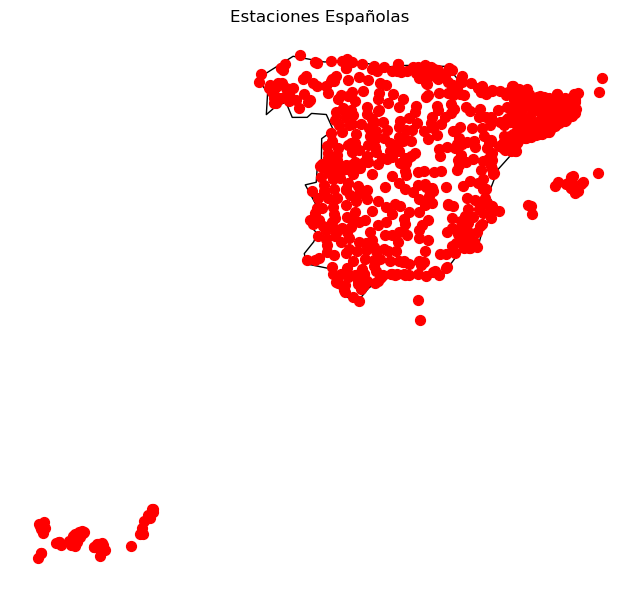

In [8]:
#Gráfica con todas las estaciones
fig, ax = plt.subplots(figsize=(8, 10))
spain.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Españolas")
plt.axis("off")
plt.show()

In [9]:
#Lista de IDs de estaciones españolas
lista_estaciones_espanolas=metadata_ESP.STAID.to_list()

In [10]:
#Definición del dataframe con información de la primera estación
station='FG_STAID000000'
station_i=station[:-len(str(lista_estaciones_espanolas[0]))]+str(lista_estaciones_espanolas[0])
data=pd.read_csv('../Datos en bruto/Meteorologicos/Viento/'+str(station_i)+'.txt',skiprows=20,sep=",")
data.columns=data.columns.str.strip()
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2013-01-01') & (data.Q_FG!=9)]
data_unif=data.loc[:,['DATE','FG']]
data_unif.set_index('DATE', inplace=True)
data_unif

,FG
DATE,
2013-01-01,14
2013-01-02,3
2013-01-03,39
2013-01-04,31
2013-01-05,11
...,...
2025-03-25,17
2025-03-26,14
2025-03-27,14


In [11]:
#Anexión de la información del resto de estaciones meteorológicas
for i in lista_estaciones_espanolas[1:]:
    station='FG_STAID000000'
    station_i=station[:-len(str(i))]+str(i)
    data=pd.read_csv('../Datos en bruto/Meteorologicos/Viento/'+station_i+'.txt',skiprows=20,sep=",")
    data.columns=data.columns.str.strip()
    data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
    data=data[(data.DATE>='2013-01-01') & (data.Q_FG!=9)]
    df=data.loc[:,['DATE','FG']]
    df.set_index('DATE', inplace=True)
    data_unif['FG '+str(i)]=df

data_unif

,FG,FG 231,FG 232,FG 233,FG 236,FG 237,FG 309,FG 336,FG 337,FG 412,...,FG 27656,FG 27664,FG 27665,FG 27667,FG 27670,FG 27672,FG 27679,FG 27683,FG 27684,FG 27696
DATE,,,,,,,,,,,,,,,,,,,,,
2013-01-01,14,58,42.0,28.0,36.0,19.0,56.0,36.0,6.0,17.0,...,22.0,28.0,28.0,36.0,122.0,22.0,39.0,22.0,14.0,19.0
2013-01-02,3,53,22.0,17.0,44.0,11.0,28.0,47.0,17.0,19.0,...,19.0,42.0,42.0,44.0,106.0,31.0,31.0,0.0,19.0,28.0
2013-01-03,39,56,17.0,19.0,36.0,3.0,47.0,19.0,31.0,25.0,...,14.0,14.0,14.0,11.0,28.0,14.0,11.0,8.0,8.0,31.0
2013-01-04,31,31,22.0,11.0,31.0,22.0,28.0,11.0,28.0,22.0,...,14.0,8.0,8.0,3.0,56.0,3.0,6.0,44.0,3.0,6.0
2013-01-05,11,56,25.0,6.0,28.0,17.0,39.0,33.0,14.0,14.0,...,14.0,11.0,11.0,6.0,86.0,8.0,3.0,22.0,6.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-25,17,36,28.0,39.0,28.0,14.0,33.0,36.0,19.0,19.0,...,19.0,31.0,31.0,22.0,33.0,25.0,22.0,17.0,14.0,19.0
2025-03-26,14,25,36.0,14.0,50.0,22.0,50.0,39.0,17.0,25.0,...,14.0,25.0,25.0,22.0,67.0,14.0,19.0,19.0,19.0,19.0
2025-03-27,14,42,31.0,33.0,25.0,19.0,31.0,47.0,22.0,19.0,...,14.0,33.0,33.0,31.0,47.0,19.0,22.0,17.0,19.0,22.0


In [12]:
# Se eliminan todas aquellas estaciones que tienen datos faltantes y se renombra la primera estación con el IDs de estación
d=data_unif.dropna(axis=1)
d=d.rename({'FG':'FG 229'},axis=1)
d

,FG 229,FG 231,FG 414,FG 421,FG 425,FG 1389,FG 1396,FG 2970,FG 3839,FG 3921,...,FG 25164,FG 26867,FG 26913,FG 26955,FG 26980,FG 27045,FG 27374,FG 27422,FG 27450,FG 27479
DATE,,,,,,,,,,,,,,,,,,,,,
2013-01-01,14,58,17,39,22,19,17,58,11,36,...,27,39,14,44,10,42,11,39,19,19
2013-01-02,3,53,50,28,8,50,8,58,67,11,...,28,28,8,58,16,44,22,28,22,28
2013-01-03,39,56,39,17,14,39,8,44,6,14,...,35,61,17,67,12,33,17,53,14,22
2013-01-04,31,31,11,11,8,14,6,31,8,8,...,47,36,11,44,20,6,28,22,47,19
2013-01-05,11,56,33,22,6,17,6,42,6,11,...,53,50,17,58,23,6,14,31,11,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-25,17,36,47,25,8,28,14,92,42,14,...,36,22,25,39,8,28,31,22,22,19
2025-03-26,14,25,36,25,11,22,17,75,25,17,...,44,25,22,33,11,28,25,25,19,19
2025-03-27,14,42,44,22,11,31,14,72,14,17,...,47,17,19,33,8,28,31,31,19,17


In [13]:
# Lista de estaciones españolas sin valores faltantes
v=[]
for i in d.columns:
    v.append(int(i[3:]))
    
mt=metadata_ESP[metadata_ESP.STAID.isin(v)]
mt

,STAID,STANAME,CN,LAT,LON,HGHT
87,229,BADAJOZ AEROPUERTO,ES,38.883056,-6.813889,186
89,231,MALAGA AEROPUERTO,ES,36.665833,-4.481944,7
147,414,BURGOS AEROPUERTO,ES,42.356667,-3.620278,891
154,421,MURCIA,ES,38.001667,-1.170556,62
158,425,VALLADOLID,ES,41.640556,-4.754167,734
510,1389,MELILLA,ES,35.276389,-2.956389,52
515,1396,PONFERRADA,ES,42.563889,-6.600000,532
901,2970,LANZAROTE AEROPUERTO,ES,28.951667,-13.600278,14
1034,3839,TORREJON DE ARDOZ,ES,40.488333,-3.443333,607
1066,3921,CACERES,ES,39.471389,-6.338889,394


In [14]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(mt['LON'], mt['LAT'])] 
puntos = gpd.GeoDataFrame(mt, geometry=estaciones, crs="EPSG:4326") 

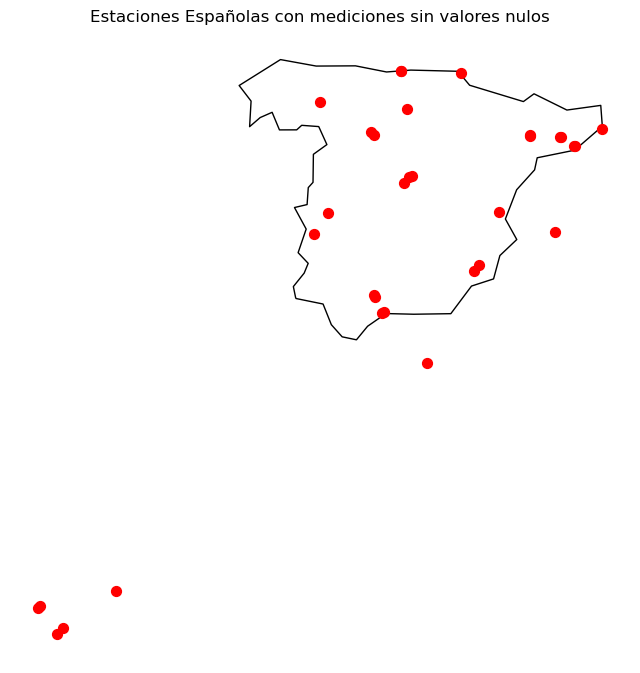

In [15]:
#Gráfica con todas las estaciones
fig, ax = plt.subplots(figsize=(8, 10))
spain.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Españolas con mediciones sin valores nulos")
plt.axis("off")
plt.show()

In [16]:
#Primer filtrado de estaciones en función del valor truncado de la longitud y latitud
w=[]
ww=[]
for x in zip(mt['LON'],mt['LAT'],mt['STAID']):
    if (math.trunc(x[0]),math.trunc(x[1])) not in w:
        w.append((math.trunc(x[0]),math.trunc(x[1])))
        ww.append(x[2])

mt_esp=mt[mt.STAID.isin(ww)]

In [17]:
#Segundo filtrado de estaciones en función del valor redondeado de la longitud y latitud
w=[]
ww=[]
for x in zip(mt_esp['LON'],mt_esp['LAT'],mt_esp['STAID']):
    if (round(x[0]),round(x[1])) not in w:
        w.append((round(x[0]),round(x[1])))
        ww.append(x[2])
        
mt_ESP=mt_esp[mt_esp.STAID.isin(ww)]
mt_ESP

,STAID,STANAME,CN,LAT,LON,HGHT
87,229,BADAJOZ AEROPUERTO,ES,38.883056,-6.813889,186
89,231,MALAGA AEROPUERTO,ES,36.665833,-4.481944,7
147,414,BURGOS AEROPUERTO,ES,42.356667,-3.620278,891
154,421,MURCIA,ES,38.001667,-1.170556,62
158,425,VALLADOLID,ES,41.640556,-4.754167,734
510,1389,MELILLA,ES,35.276389,-2.956389,52
515,1396,PONFERRADA,ES,42.563889,-6.600000,532
901,2970,LANZAROTE AEROPUERTO,ES,28.951667,-13.600278,14
1034,3839,TORREJON DE ARDOZ,ES,40.488333,-3.443333,607
1066,3921,CACERES,ES,39.471389,-6.338889,394


In [18]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(mt_ESP['LON'], mt_ESP['LAT'])] 
puntos = gpd.GeoDataFrame(mt_ESP, geometry=estaciones, crs="EPSG:4326") 

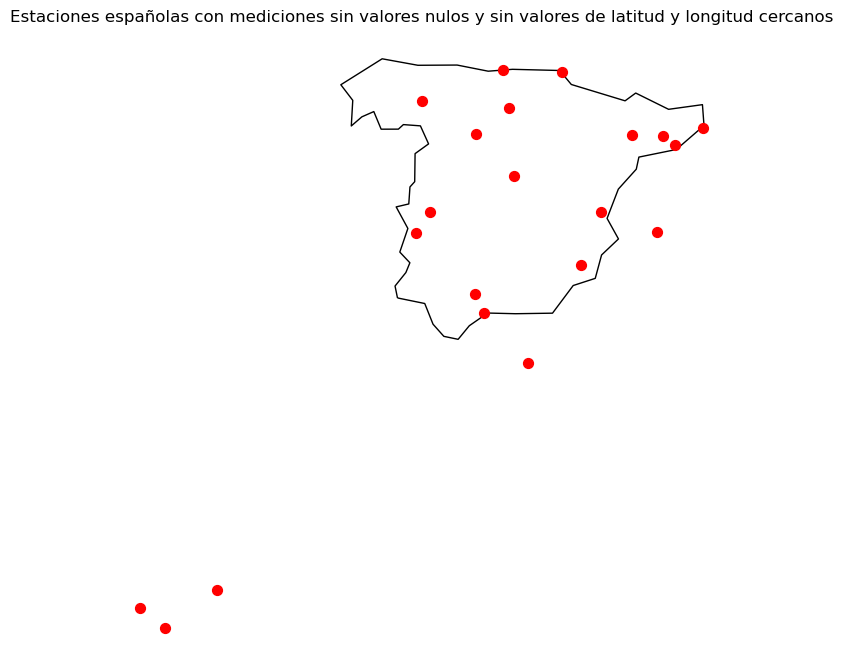

In [19]:
#Gráfica
fig, ax = plt.subplots(figsize=(8, 10))
spain.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones españolas con mediciones sin valores nulos y sin valores de latitud y longitud cercanos")
plt.axis("off")
plt.show()

In [20]:
#Agrupación de los datos diarios en datos semanales para cada estación
data=d.loc[:,['FG '+str(i) for i in mt_ESP.STAID.to_list()]]
data=data.resample('W').mean()
data

,FG 229,FG 231,FG 414,FG 421,FG 425,FG 1389,FG 1396,FG 2970,FG 3839,FG 3921,...,FG 3936,FG 3942,FG 3959,FG 3969,FG 11023,FG 11034,FG 11059,FG 11207,FG 26867,FG 27374
DATE,,,,,,,,,,,,,,,,,,,,,
2013-01-06,16.833333,56.166667,28.166667,22.666667,11.500000,32.833333,8.833333,44.833333,17.666667,15.166667,...,22.666667,8.166667,22.666667,29.000000,31.666667,37.833333,16.166667,46.333333,38.000000,18.166667
2013-01-13,23.571429,56.285714,36.000000,22.000000,19.000000,30.142857,12.285714,41.571429,16.714286,23.714286,...,19.857143,13.857143,23.714286,42.714286,21.285714,28.857143,22.571429,40.142857,36.000000,18.714286
2013-01-20,59.142857,55.714286,51.714286,39.142857,41.142857,81.000000,27.142857,62.428571,55.142857,54.000000,...,39.571429,47.142857,26.714286,78.142857,21.428571,29.428571,36.285714,67.000000,70.857143,45.285714
2013-01-27,46.857143,46.000000,44.142857,41.285714,32.142857,69.714286,13.571429,73.428571,46.285714,44.142857,...,46.571429,37.142857,25.000000,69.571429,23.000000,31.571429,35.285714,97.571429,71.857143,33.000000
2013-02-03,19.571429,38.857143,56.714286,33.714286,22.857143,30.571429,21.428571,48.857143,32.428571,20.857143,...,32.000000,34.142857,20.285714,46.857143,29.000000,32.714286,39.714286,52.000000,48.285714,19.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-02,25.428571,44.285714,45.571429,22.857143,17.857143,25.000000,19.000000,51.285714,31.285714,26.285714,...,26.285714,21.714286,30.428571,43.571429,24.000000,48.571429,7.142857,70.285714,25.428571,19.428571
2025-03-09,26.571429,32.285714,60.285714,36.000000,22.285714,27.285714,27.428571,54.285714,37.428571,39.000000,...,41.000000,30.857143,36.000000,55.285714,24.142857,73.714286,12.571429,40.857143,39.571429,28.285714
2025-03-16,25.142857,32.000000,36.571429,25.714286,14.285714,24.857143,16.285714,58.000000,32.000000,28.428571,...,29.857143,22.571429,35.571429,36.142857,20.571429,43.428571,9.571429,41.000000,22.571429,35.857143


In [21]:
#Cálculo de la media para cada semana en función del total de estaciones
a=data.mean(axis=1)
a=pd.DataFrame(a).rename({0:'FG'},axis=1)
a

,FG
DATE,
2013-01-06,26.095238
2013-01-13,27.102041
2013-01-20,49.938776
2013-01-27,46.659864
2013-02-03,34.544218
...,...
2025-03-02,31.666667
2025-03-09,37.414966
2025-03-16,29.843537


In [22]:
#Exportación de datos semanales de la velocidad del viento en España
a.to_csv('viento_semanal_esp.csv',index=True,encoding='utf-8')

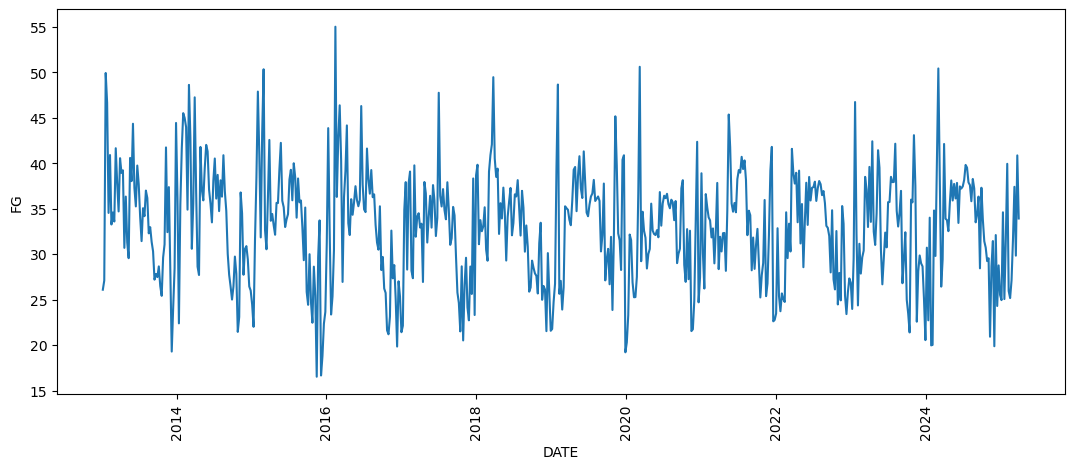

In [23]:
#Visualización de datos mensuales
plt.figure(figsize=(13,5))
sns.lineplot(data=a,x=a.index,y=a.FG)
plt.xticks(rotation=90)
plt.show()